## Data-Driven Discovery of a Discrete-Time Recurrence

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error


def plot_username():
    plt.text(0.95, 0.95, "harshit.goyal",ha='right', va='top',transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)

###  Dataset and Problem Setup

In [ ]:
class TimeSeriesHandler:
    """
    Utility class for loading a univariate series, splitting it,
    normalizing it, and generating supervised learning pairs.
    """

    def __init__(self, filepath):

        self.scaler = MinMaxScaler(feature_range=(0, 1))
        self.data_raw = None
        self.series = None

        try:
            df = pd.read_csv(filepath)
            self.data_raw = df

            # Try to use 'x_value'; fallback to first column
            col = "x_value"
            if col in df.columns:
                self.series = df[col].astype(float).to_numpy()
            else:
                print(f"[Notice] Column '{col}' not present. Using first column instead.")
                self.series = df.iloc[:, 0].astype(float).to_numpy()

            print(f"[OK] Loaded dataset with {self.series.size} points.")

        except FileNotFoundError:
            print(f"[Error] File '{filepath}' does not exist.")
        except Exception as exc:
            print(f"[Error] Could not load file: {exc}")

        # placeholders
        self.train = None
        self.valid = None
        self.test = None

    # -------------------------------------------------------------
    def split(self, train_ratio=0.70, valid_ratio=0.15):
        """
        Chronological split into train/validation/test sets.
        """
        if self.series is None:
            print("[Error] No series loaded.")
            return

        n = len(self.series)
        t_end = int(n * train_ratio)
        v_end = int(n * (train_ratio + valid_ratio))

        self.train = self.series[:t_end]
        self.valid = self.series[t_end:v_end]
        self.test = self.series[v_end:]

        print(f"[Split] Train: {len(self.train)}, "
              f"Valid: {len(self.valid)}, Test: {len(self.test)}")

    # -------------------------------------------------------------
    def fit_scaler(self):
        """
        Fit MinMax scaler using *only* the training portion.
        """
        if self.train is None:
            print("[Error] Split data before fitting scaler.")
            return

        reshaped = self.train.reshape(-1, 1)
        self.scaler.fit(reshaped)
        print("[Scaler] Fitted on training data.")

    # -------------------------------------------------------------
    def normalize(self):
        """
        Normalize the train/valid/test series using the fitted scaler.
        Prints shapes directly for notebook debugging.
        """
        if not hasattr(self.scaler, "scale_"):
            print("[Error] Fit the scaler first.")
            return None, None, None

        t = self.scaler.transform(self.train.reshape(-1, 1)).ravel()
        v = self.scaler.transform(self.valid.reshape(-1, 1)).ravel()
        s = self.scaler.transform(self.test.reshape(-1, 1)).ravel()

        print("[Norm] Shapes — Train:", t.shape, "Valid:", v.shape, "Test:", s.shape)
        return t, v, s

    def undo_scale(self, arr):
        """
        Return array to original scale.
        """
        arr = np.asarray(arr).reshape(-1, 1)
        return self.scaler.inverse_transform(arr).ravel()

    @staticmethod
    def make_supervised(series, window):
        """
        Build supervised learning pairs (X,y) for window-based prediction.
        """
        X, y = [], []
        limit = len(series) - window

        for i in range(limit):
            X.append(series[i:i + window])
            y.append(series[i + window])

        X = np.array(X)
        y = np.array(y)

        print(f"[Supervised] Created {X.shape[0]} samples with window={window}")
        return X, y


### Sequence Prediction

In [ ]:
class FeedForwardNet(nn.Module):
    """
    A compact MLP used for one-step time series forecasting.
    """
    def __init__(self, window, width=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(window, width),
            nn.ReLU(),
            nn.Linear(width, width),
            nn.ReLU(),
            nn.Linear(width, 1)
        )

        print(f"[Model] MLP created → Input:{window}, Hidden:{width}")

    def forward(self, x):
        return self.net(x)


class SimpleRNNForecaster(nn.Module):
    """
    Recurrent model for window-based time series prediction.
    Uses PyTorch's vanilla RNN layer.
    """
    def __init__(self, input_features=1, hidden=50, layers=1):
        super().__init__()

        self.hidden_dim = hidden
        self.n_layers = layers

        self.rnn = nn.RNN(
            input_size=input_features,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True,
            nonlinearity="tanh"
        )

        self.out_layer = nn.Linear(hidden, 1)

        print(f"[Model] RNN initialized → Hidden:{hidden}, Layers:{layers}")

    def forward(self, x):
        # Expected input: (batch, time_steps)
        if x.ndim == 2:
            x = x.unsqueeze(-1)  # add input feature dimension

        batch_size = x.size(0)

        # Initial hidden state
        h0 = torch.zeros(self.n_layers, batch_size, self.hidden_dim, device=x.device)

        # Full sequence output (we only need last step)
        rnn_out, _ = self.rnn(x, h0)

        # Use the last time-step output
        prediction = self.out_layer(rnn_out[:, -1, :])
        return prediction


In [ ]:

def train_model_torch(net, train_loader, valid_loader, *,
                      epochs=50, lr=1e-3, device="cpu"):
    """
    Train a PyTorch model and return the best validation MSE.
    Minimal printing; models are kept in memory.
    """
    net = net.to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_val = float("inf")

    for ep in range(1, epochs + 1):
        # -------- Training --------
        net.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            opt.zero_grad()
            out = net(xb)
            loss = loss_fn(out, yb.unsqueeze(1))
            loss.backward()
            opt.step()

        # -------- Validation --------
        net.eval()
        val_losses = []
        with torch.no_grad():
            for xv, yv in valid_loader:
                xv, yv = xv.to(device), yv.to(device)
                pv = net(xv)
                val_losses.append(loss_fn(pv, yv.unsqueeze(1)).item())

        mean_val = np.mean(val_losses)
        if mean_val < best_val:
            best_val = mean_val

    return best_val


def count_parameters(net):
    """Count total trainable parameters."""
    return sum(p.numel() for p in net.parameters() if p.requires_grad)



DATA_FILE = "/kaggle/input/timeseries/recurrence_timeseries.csv"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Active Device: {DEVICE}")

handler = TimeSeriesHandler(DATA_FILE)
handler.split(train_ratio=0.7, valid_ratio=0.15)
handler.fit_scaler()
train_norm, valid_norm, test_norm = handler.normalize()


p_candidates = range(2, 15)
model_names = ["Linear", "MLP", "RNN"]

best_models = {}
best_meta = {}
search_log = []

print("\n================ HYPERPARAMETER SEARCH ================\n")

for model_name in model_names:
    print(f"→ Tuning {model_name}...", end="")

    optimal_p = None
    optimal_mse = float("inf")
    optimal_params = None
    optimal_model = None

    p_records = []

    for p in p_candidates:
        # Build supervised data for this p
        Xtr, ytr = handler.make_supervised(train_norm, p)
        Xva, yva = handler.make_supervised(valid_norm, p)

        if len(Xtr) == 0 or len(Xva) == 0:
            continue

        # -------- Linear AR --------
        if model_name == "Linear":
            model = LinearRegression()
            model.fit(Xtr, ytr)
            preds = model.predict(Xva)
            mse = mean_squared_error(yva, preds)
            n_params = p + 1  # p weights + bias

        # -------- MLP / RNN --------
        else:
            train_loader = DataLoader(
                TensorDataset(torch.tensor(Xtr).float(), torch.tensor(ytr).float()),
                batch_size=32, shuffle=True
            )
            val_loader = DataLoader(
                TensorDataset(torch.tensor(Xva).float(), torch.tensor(yva).float()),
                batch_size=32, shuffle=False
            )

            if model_name == "MLP":
                model = FeedForwardNet(window=p, width=64)
            else:
                model = SimpleRNNForecaster(input_features=1, hidden=50, layers=1)

            n_params = count_parameters(model)

            mse = train_model_torch(
                model,
                train_loader,
                val_loader,
                epochs=50,
                lr=1e-3,
                device=DEVICE
            )

        p_records.append({"p": p, "val_mse": mse})

        # Update best config for this model
        if mse < optimal_mse:
            optimal_mse = mse
            optimal_p = p
            optimal_params = n_params
            optimal_model = model

    print(f" best p={optimal_p}, MSE={optimal_mse:.6f}")

    # Store best model IN MEMORY
    best_models[model_name] = optimal_model
    best_meta[model_name] = {
        "p": optimal_p,
        "mse": optimal_mse,
        "params": optimal_params,
    }

    search_log.append({
        "model": model_name,
        "best_p": optimal_p,
        "best_val_mse": optimal_mse,
        "params": optimal_params
    })


print("\n================ FINAL SUMMARY ================\n")
summary_df = pd.DataFrame(search_log)
display(summary_df)


Active Device: cuda
[OK] Loaded dataset with 54000 points.
[Split] Train: 37800, Valid: 8100, Test: 8100
[Scaler] Fitted on training data.
[Norm] Shapes — Train: (37800,) Valid: (8100,) Test: (8100,)

================ HYPERPARAMETER SEARCH ================

→ Tuning Linear...[Supervised] Created 37798 samples with window=2
[Supervised] Created 8098 samples with window=2
[Supervised] Created 37797 samples with window=3
[Supervised] Created 8097 samples with window=3
[Supervised] Created 37796 samples with window=4
[Supervised] Created 8096 samples with window=4
[Supervised] Created 37795 samples with window=5
[Supervised] Created 8095 samples with window=5
[Supervised] Created 37794 samples with window=6
[Supervised] Created 8094 samples with window=6
[Supervised] Created 37793 samples with window=7
[Supervised] Created 8093 samples with window=7
[Supervised] Created 37792 samples with window=8
[Supervised] Created 8092 samples with window=8
[Supervised] Created 37791 samples with windo

,model,best_p,best_val_mse,params
0,Linear,13,0.006279,14
1,MLP,12,0.006188,5057
2,RNN,8,0.006272,2701


###  Analytical Recurrence Identification

In [ ]:
SEARCH_P = range(2, 15)
RIDGE_STRENGTH = 0.1

print("### Discovering Analytical Recurrence F_θ ###")

# Load + normalize data
handler = TimeSeriesHandler(DATA_FILE)
handler.split()
handler.fit_scaler()

train_norm, val_norm, _ = handler.normalize()

print("\nSearching for best history length p...")

best_p = None
best_mse = float("inf")
best_model = None

for p in SEARCH_P:
    Xtr, ytr = handler.make_supervised(train_norm, p)
    Xva, yva = handler.make_supervised(val_norm, p)

    if len(Xtr) == 0 or len(Xva) == 0:
        continue

    model = Ridge(alpha=RIDGE_STRENGTH)
    model.fit(Xtr, ytr)

    val_pred = model.predict(Xva)
    mse = mean_squared_error(yva, val_pred)

    print(f"  p={p:2d} → Val MSE={mse:.6f}")

    if mse < best_mse:
        best_mse = mse
        best_p = p
        best_model = model    # store actual trained model!


print(f"\n### Best p: {best_p}  |  Validation MSE: {best_mse:.6f} ###")

b0 = best_model.intercept_
coef = best_model.coef_

print("\n### Identified Closed-Form Recurrence F_θ ###")

formula = f"x_k = {b0:.4f} "
for i, c in enumerate(coef):
    if abs(c) > 1e-4:
        sign = "+" if c >= 0 else "-"
        formula += f"{sign} {abs(c):.4f} * x_(k-{i+1}) "

print("\nF_θ (Compact Form):")
print(formula)

best_models["F_theta"] = best_model
best_meta["F_theta"] = {
    "p": best_p,
    "mse": best_mse,
    "params": best_p + 1    # coefficients + intercept
}

identified_F_theta = {
    "p": best_p,
    "intercept": float(b0),
    "coefficients": [float(v) for v in coef]
}

print("\nStored F_θ into: best_models['F_theta'] and best_meta['F_theta']")
print("Also saved coefficients to `identified_F_theta`.")


### Discovering Analytical Recurrence F_θ ###
[OK] Loaded dataset with 54000 points.
[Split] Train: 37800, Valid: 8100, Test: 8100
[Scaler] Fitted on training data.
[Norm] Shapes — Train: (37800,) Valid: (8100,) Test: (8100,)

Searching for best history length p...
[Supervised] Created 37798 samples with window=2
[Supervised] Created 8098 samples with window=2
  p= 2 → Val MSE=0.006618
[Supervised] Created 37797 samples with window=3
[Supervised] Created 8097 samples with window=3
  p= 3 → Val MSE=0.006614
[Supervised] Created 37796 samples with window=4
[Supervised] Created 8096 samples with window=4
  p= 4 → Val MSE=0.006599
[Supervised] Created 37795 samples with window=5
[Supervised] Created 8095 samples with window=5
  p= 5 → Val MSE=0.006569
[Supervised] Created 37794 samples with window=6
[Supervised] Created 8094 samples with window=6
  p= 6 → Val MSE=0.006514
[Supervised] Created 37793 samples with window=7
[Supervised] Created 8093 samples with window=7
  p= 7 → Val MSE=0.006

In [ ]:
def show_residuals(y_true, y_pred, label):
    """Inline histogram of residuals."""
    res = y_true - y_pred

    plt.figure(figsize=(10, 5))
    plt.hist(res, bins=40, alpha=0.75)
    plt.axvline(0, linestyle="--", color="red")
    plt.title(f"Residual Distribution — {label}")
    plt.xlabel("Error")
    plt.ylabel("Count")
    plot_username()
    plt.show()


def rollout(model, history, steps, *, model_type="sklearn", device="cpu"):
    """
    Autoregressive rollout for sklearn or torch models.
    Returns predicted sequence of length `steps`.
    """
    h = list(history)
    p = len(history)
    preds = []

    if model_type != "sklearn":
        model.eval()
        model.to(device)

    for _ in range(steps):
        last = np.array(h[-p:], dtype=float)

        if model_type == "sklearn":
            nxt = model.predict(last.reshape(1, -1))[0]
        else:
            inp = torch.tensor(last, dtype=torch.float).reshape(1, -1).to(device)
            if model_type == "rnn":
                inp = inp.unsqueeze(-1)
            with torch.no_grad():
                nxt = model(inp).item()

        preds.append(nxt)
        h.append(nxt)

    return np.array(preds)


def compare_rollouts(models, test_series, steps):
    """
    Given dict:
        models[name] = {"p": value, "model": model, "type": ...}
    Plot rollouts vs true series.
    """
    plt.figure(figsize=(13, 7))

    # True data
    max_p = max(m["p"] for m in models.values())
    init = test_series[:max_p]
    true_future = test_series[max_p:max_p + steps]
    plt.plot(true_future, "k--", linewidth=2.5, label="True")

    # Model rollouts
    for name, m in models.items():
        p = m["p"]
        hist = test_series[max_p - p:max_p]
        pred = rollout(m["model"], hist, steps,
                       model_type=m["type"], device=DEVICE)
        plt.plot(pred, label=f"{name} (p={p})", alpha=0.85)

    plt.title("Autoregressive Rollout Comparison")
    plt.xlabel("Step")
    plt.ylabel("Normalized Value")
    plot_username()
    plt.legend()
    plt.show()


def error_vs_horizon(models, test_series, max_h):
    """
    Compute MSE as horizon increases.
    """
    plt.figure(figsize=(12, 6))
    print(f"Computing error up to horizon {max_h}…")

    for name, m in models.items():
        p = m["p"]
        model = m["model"]
        kind = m["type"]

        X, y = TimeSeriesHandler.make_supervised(test_series, p)
        usable = len(X) - max_h
        if usable <= 0:
            print(f"Skipping {name}: insufficient test points.")
            continue

        preds = []
        trues = []

        for idx in range(usable):
            hist = X[idx]
            seq_pred = rollout(model, hist, max_h,
                               model_type=kind, device=DEVICE)
            preds.append(seq_pred)
            trues.append(test_series[idx+p : idx+p+max_h])

        preds = np.array(preds)
        trues = np.array(trues)
        mse_curve = ((preds - trues) ** 2).mean(axis=0)

        plt.plot(np.arange(1, max_h+1), mse_curve,
                 label=f"{name} (p={p})")

    plt.yscale("log")
    plt.grid(True, alpha=0.4)
    plt.title("Error vs Forecast Horizon")
    plt.xlabel("Horizon h")
    plt.ylabel("MSE (log scale)")
    plot_username()
    plt.legend()
    plt.show()

def plot_complexity(results):
    """
    results = [
        {"Model": "...", "Params": ..., "MSE": ...},
    ]
    """
    plt.figure(figsize=(10, 6))

    for r in results:
        plt.scatter(r["Params"], r["MSE"], s=130)
        plt.text(r["Params"] * 1.05, r["MSE"], r["Model"])

    plt.xscale("log")
    plt.yscale("log")
    plt.grid(True, alpha=0.4)
    plt.title("Model Complexity vs Test Error")
    plt.xlabel("Parameter Count (log)")
    plt.ylabel("Test MSE (log)")
    plot_username()
    plt.show()



Device: cuda
[OK] Loaded dataset with 54000 points.
[Split] Train: 37800, Valid: 8100, Test: 8100
[Scaler] Fitted on training data.
[Norm] Shapes — Train: (37800,) Valid: (8100,) Test: (8100,)

Models: ['Linear', 'MLP', 'RNN', 'F_theta']
[Supervised] Created 8087 samples with window=13
Linear: MSE=0.00587, MAE=0.01934


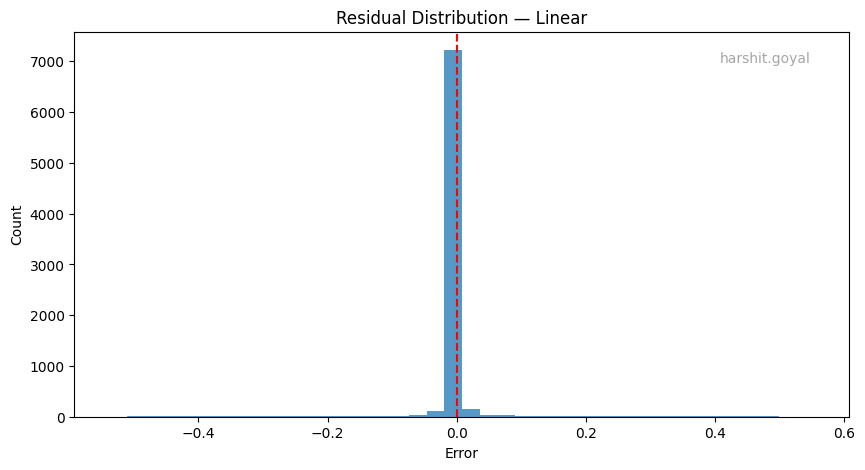

[Supervised] Created 8088 samples with window=12
MLP: MSE=0.00594, MAE=0.02090


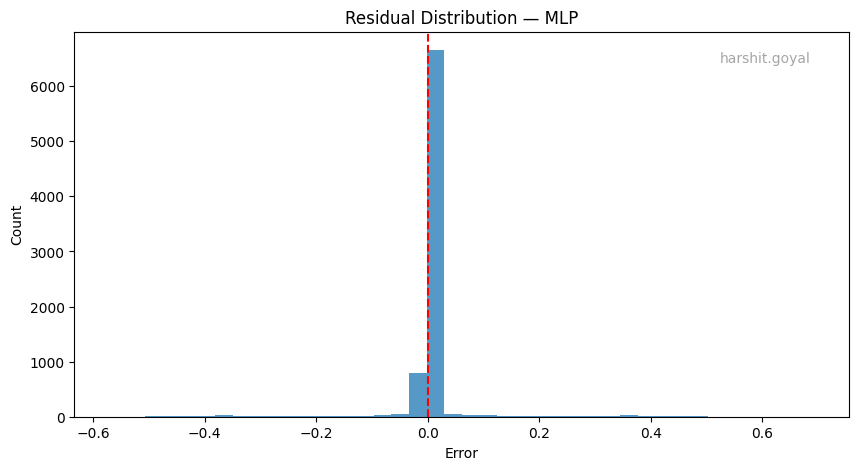

[Supervised] Created 8092 samples with window=8
RNN: MSE=0.00594, MAE=0.02281


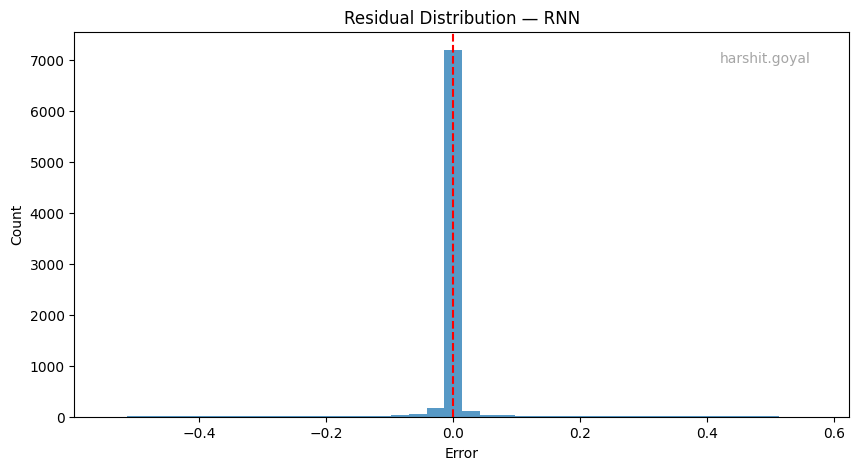

[Supervised] Created 8087 samples with window=13
F_theta: MSE=0.00587, MAE=0.01934


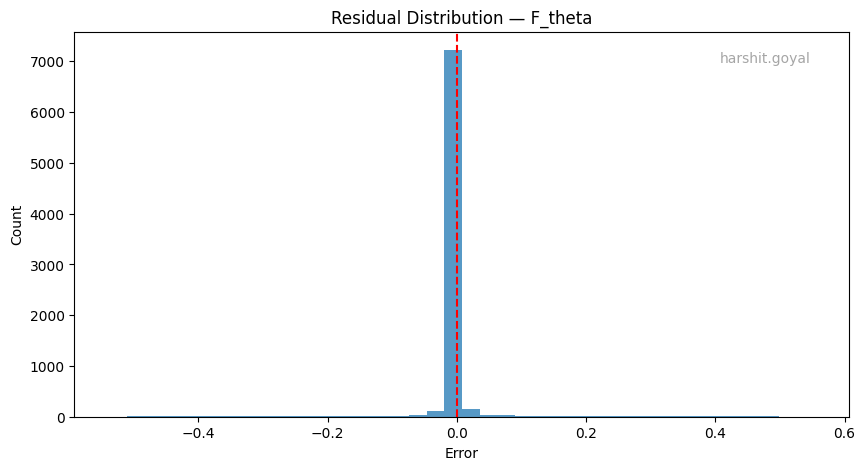

,Model,p,MSE,MAE,Params
0,Linear,13,0.005871,0.019338,14
1,MLP,12,0.005944,0.020904,5057
2,RNN,8,0.005939,0.022814,2701
3,F_theta,13,0.005871,0.019339,14



Rollout comparison...


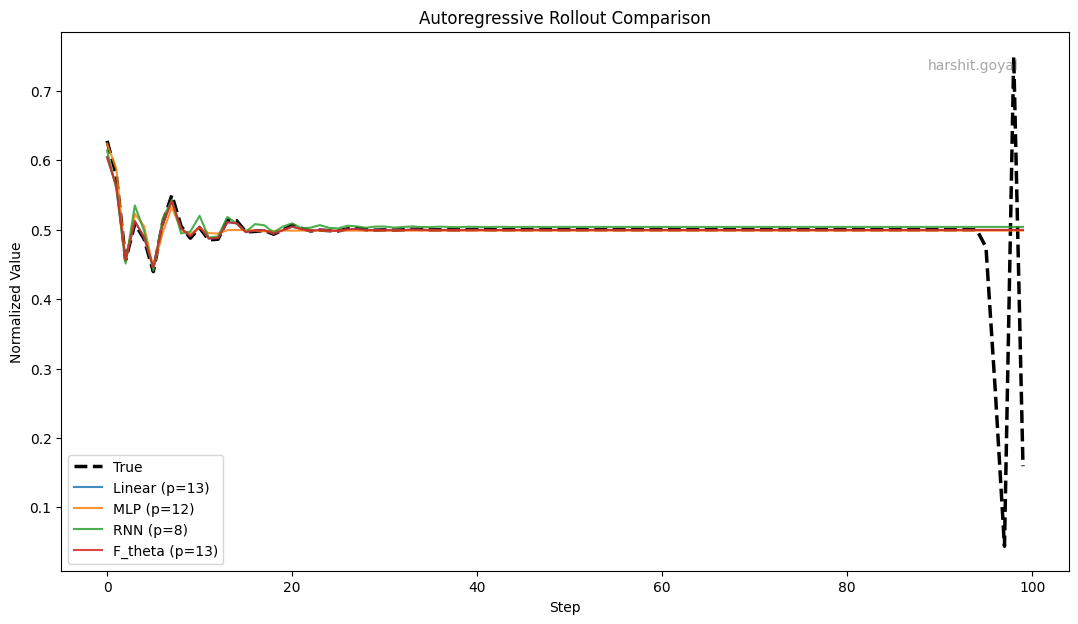

Computing error vs horizon...
Computing error up to horizon 20…
[Supervised] Created 8087 samples with window=13
[Supervised] Created 8088 samples with window=12
[Supervised] Created 8092 samples with window=8
[Supervised] Created 8087 samples with window=13


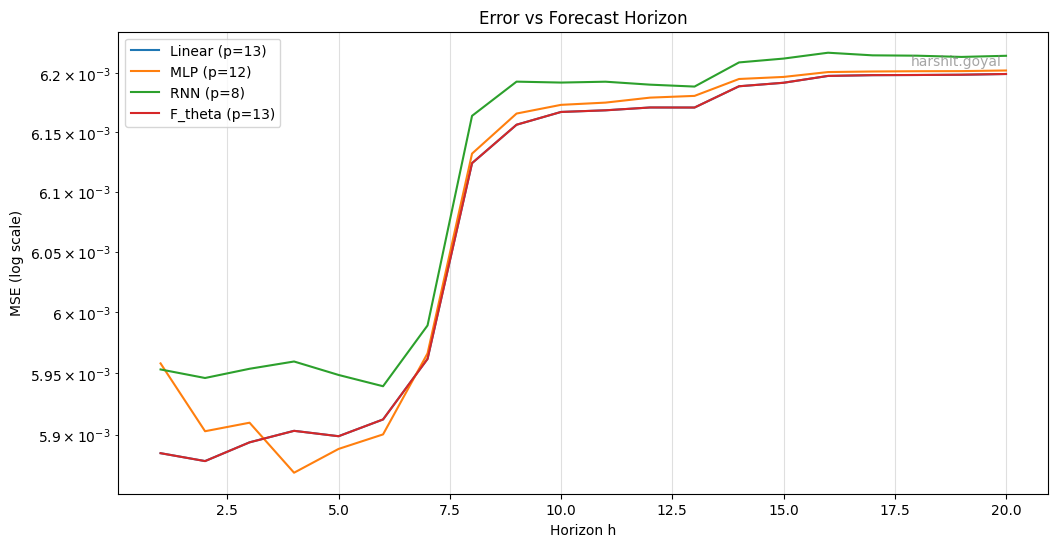

Complexity vs accuracy...


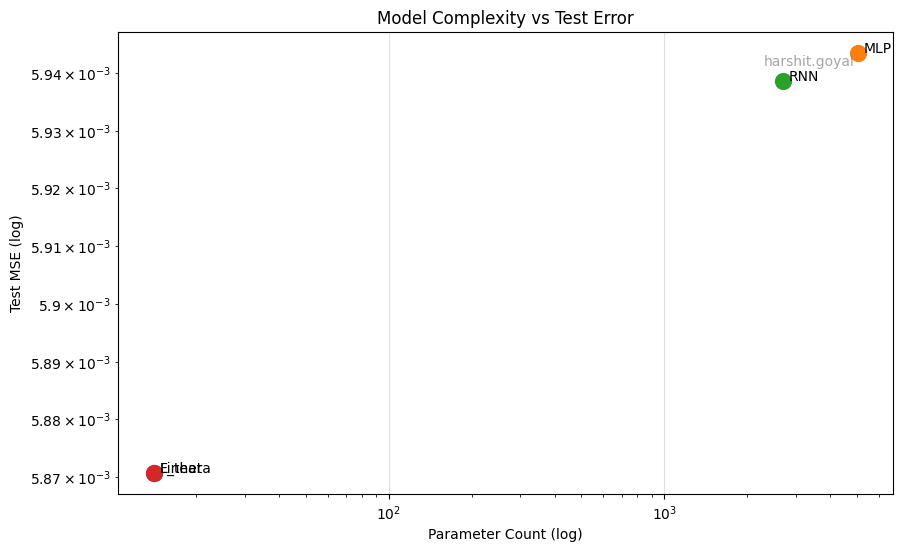


Analysis complete.


In [ ]:

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_ROLLOUT_STEPS = 100
HORIZON_STEPS = 20

print(f"Device: {DEVICE}")

handler = TimeSeriesHandler(DATA_FILE)
handler.split()
handler.fit_scaler()
_, _, test_norm = handler.normalize()


models_data = {}

for name in best_models:
    models_data[name] = {
        "model": best_models[name],
        "p": best_meta[name]["p"],
        "type": (
            "sklearn" 
            if name in ["Linear", "F_theta"] 
            else "torch_mlp" if name == "MLP" 
            else "rnn"
        ),
        "param_count": best_meta[name]["params"]
    }

print("\nModels:", list(models_data.keys()))


results_table = []

for name, info in models_data.items():
    p = info["p"]
    model = info["model"]
    mtype = info["type"]
    params = info["param_count"]

    Xtest, ytest = TimeSeriesHandler.make_supervised(test_norm, p)
    if len(Xtest) == 0:
        continue

    if mtype == "sklearn":
        preds = model.predict(Xtest)
    else:
        model.eval()
        X_tensor = torch.tensor(Xtest, dtype=torch.float).to(DEVICE)
        if mtype == "rnn":
            X_tensor = X_tensor.unsqueeze(-1)
        with torch.no_grad():
            preds = model(X_tensor).cpu().numpy().flatten()

    mse = ((preds - ytest)**2).mean()
    mae = np.abs(preds - ytest).mean()

    results_table.append({
        "Model": name,
        "p": p,
        "MSE": mse,
        "MAE": mae,
        "Params": params
    })

    print(f"{name}: MSE={mse:.5f}, MAE={mae:.5f}")

    show_residuals(ytest, preds, name)


# Display results
display(pd.DataFrame(results_table))

print("\nRollout comparison...")
compare_rollouts(models_data, test_norm, N_ROLLOUT_STEPS)

print("Computing error vs horizon...")
error_vs_horizon(models_data, test_norm, HORIZON_STEPS)

print("Complexity vs accuracy...")
plot_complexity(results_table)

print("\nAnalysis complete.")